# Question 9

## Theory

Gradient Decent is a technique to reach the global mininum of a functin by adjust weigts based on a partial derivative of error functions. It is more so based on finding such an error via subtracting a desiered output from a predicted output. This can be stated specifically as:

$e(w) = d(x)-o(x) = d - \sum_{j=0}^m x_j w_j$

- d: the desiered output
- o: the predicted output
- x: the input values of the instance
- w: the weight associated with each instance. 

The gradient descent rule operates primarily via a quadratic of the error squared i.e., the root mean error squared, expressed as $E(w)$, where 

$E(w) = \frac{1}{2} e^2$

As the function is quadratic, it reaches a lowest point known as the global mininum, which gives the best line of fit/hyperbolic plane for proper class seperation.

Without getting into too much detail the weights of a function are adjusted based on partial derivatives relative to each individual weight. 

$w (k+1) = w(k) - \eta \frac{\partial E(W)}{\partial w}$

The partial derivative, due to the predicted output subtracted from the desiered output, cancles out the subtracted, resulted in the initial weight being added to the error calculated weight.

This all evaluates as the initial weight gradient added to the new weight gradient multiplied by a learning coefficient $\eta$ and the error of desiered subracted from predicted outputs multipled by the values of each instances. There are two Gradient descent learning rules that can be applied, the general Gradient Descent Learning Rule:

$w_i (k+1) = w_i (k) + \Delta w(i)$
$w_i (k+1) = w_i (k) + \eta \sum_{n}(d(n)-o(n)x_i (n))$

Which utilizes a batch sum of instances, or Gradient Descent that uses the Delta Rule, i.e., AdaLine: Adaptive Linear Elements, to update the weights via one randomly selected instance

$w (k+1) = w(k) + \eta (d(n)-o(n))x(n)$



## Implimentation of theory


For this question, two functions of two dimensions are given

$f_1 (x,y) = (x-2)^2 + (y-3)^2$

$f_2 (x,y) = (1- (y-3))^2 + 20((x+3) - (y-3)^2)^2$

To evaluate gradient descent with repsect to $f_1 (x,y)$ and $f_2 (x,y)$, their partial derivatives with respect to x and y can be evaluated.

For $f_1 (x,y)$:

partial derivative with respect to x: 
$2(x-2)$

partial derivative with respect to y: 
$2(y-3)$

Ergo, the global mininum for $f_1 (x,y)$ is $f_1 (2,3)$

For $f_2 (x,y)$

partial derivative with respect to x: 
$40((x+3)-(y-3)^2)$

partial derivative with respect to y:
$-2(1-(y-3))-80((x+3)-(y-3)^2)(y-3)$

Ergo,the global mininum for $f_2 (x,y) is $f_2 (x,y)$ is $f_2 (-2,4)$


Follwing the weight updating rule $w_i (k+1) = w_i (k) - \eta \Delta w_i$

The functions for updating x and y values corresponding to a global minimum for the gradients can follow this form:

$x_(k+1) = x(k) - \eta * \frac{\partial f}{\partial x}$

$y(k+1) = y(k) - \eta * \frac{\partial f}{\partial y}$ 

In [57]:
# imports 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Union


## Q9.1

Plotting $f_1 (x,y)$ and $f_2 (x,y)$

In [4]:
# Define functions f_1(x,y) and f_2(x,y) 
# 
# f_1(x,y) and f_2(x,y) are two dimensional. As such, plottin them invovles a 
# third dimension, as opposed to an f(x) function. One method to do this is via a meshgrid
# As such, the functions are plooted on the Z-axis relative to x and y
# for f_1(x,y) and f_2(x,y)= where Z = f(x,y)

# Initialize mesgrid for plotting and setting x and y values:

x_val = np.linspace(-15, 15, 100)
y_val = np.linspace(-15, 15, 100)
x, y = np.meshgrid(x_val, y_val)

# Set the original functions f_1(x,y) and f_2(x,y) as z_1 and z_2
z_1 = ((x-2)**2)  + ((y-3)**2)
z_2 = (1-(y-3))**2 + 20*((x+3)-(y-3)**2)**2


Plotting can be done in either of two ways, as a 2D contour map or a 3D surface.

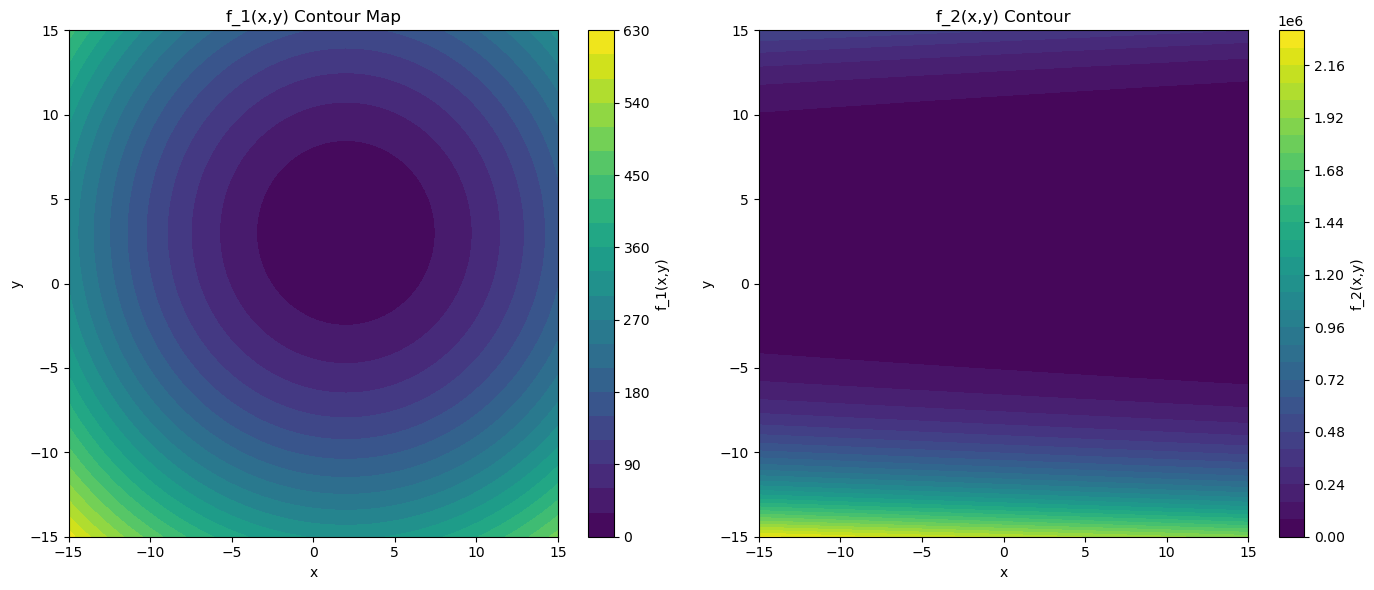

In [5]:
# Plotting as a 2D-contour map

# Set up 2D plot 
fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for f_1
cp1 = ax_1.contourf(x_val, y_val, z_1, levels=20, cmap="viridis")
fig.colorbar(cp1, ax=ax_1, label="f_1(x,y)")
ax_1.set_title("f_1(x,y) Contour Map")
ax_1.set_xlabel("x")
ax_1.set_ylabel("y")

# Plot f_2 
cp2 = ax_2.contourf(x_val, y_val, z_2, levels=30, cmap="viridis")
fig.colorbar(cp2, ax=ax_2, label="f_2(x,y)")
ax_2.set_title("f_2(x,y) Contour")
ax_2.set_xlabel("x")
ax_2.set_ylabel("y")

plt.tight_layout()
plt.show()

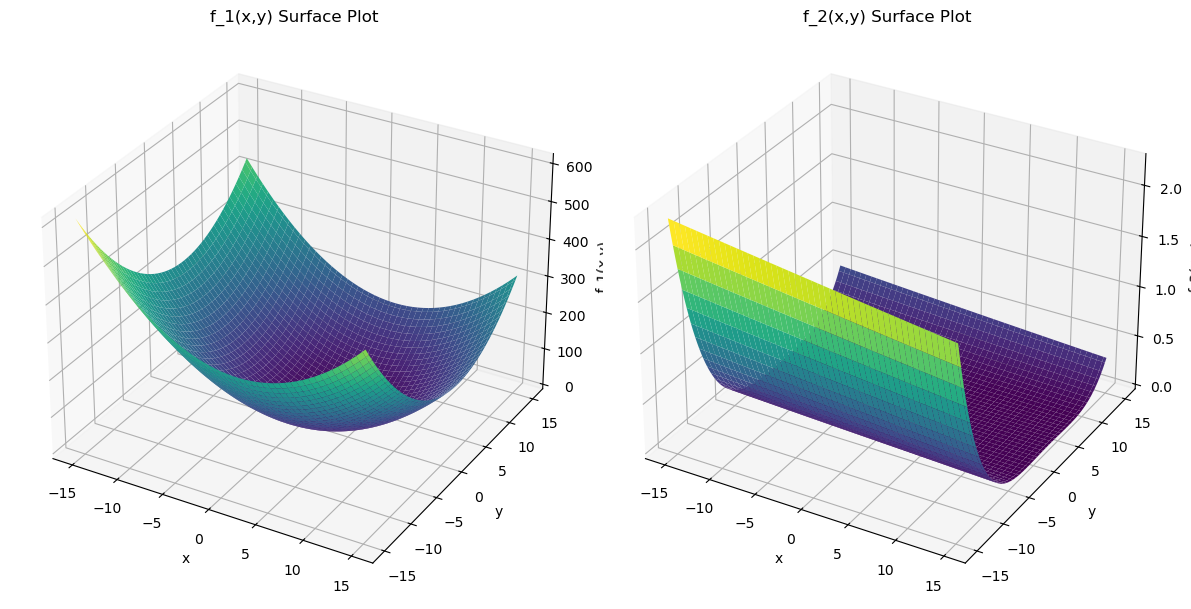

In [6]:
# Plotting as 3d surfaces

# 3d plots
fig = plt.figure(figsize=(12,6))

#f_1 plot
ax_1 = fig.add_subplot(121, projection = '3d')
ax_1.plot_surface(x, y, z_1, cmap = 'viridis')
ax_1.set_title('f_1(x,y) Surface Plot')
ax_1.set_xlabel('x')
ax_1.set_ylabel('y')
ax_1.set_zlabel('f_1(x,y)')

#f_2 plot
ax_2 = fig.add_subplot(122, projection='3d')
ax_2.plot_surface(x, y, z_2, cmap='viridis')
ax_2.set_title('f_2(x,y) Surface Plot')
ax_2.set_xlabel('x')
ax_2.set_ylabel('y')
ax_2.set_zlabel('f_2(x,y)')

plt.tight_layout()
plt.show()

##Q9.2 

Applying gradient descent to $f_1 (x,y)$ and $f_2 (x,y)$

Like gradient descent for weight updates within a dataset, x inputs are updated with values that lead to the global mininum of the functions.

Gradient Descent updating can be defined as functions $f_1 (x,y)$ and $f_2 (x,y)$

In [52]:
def f_1_GD(x1=0, y1=0, eta=0.5, T=100 ):

    """A definition for conducting gradient descent for f_1 (x,y) function  to find 
    a global mininum for x and y values for the funciton. Arguments include learning rule eta; 
    ;iteration T. x1 and y1 are initialized to 0 values for the x and y variables

    """

    # applying gradient descent to find global mininum for x and y values for f_1(x,y)

    # helper function: compute f_1 value
    def compute_f1(x,y): 
        val = (x - 2) ** 2 + (y - 3) ** 2
        return val

    # initialize arrays
    f_1_x_update = [x1];
    f_1_y_update = [y1];

    # initialize update function f_1(x,y) array to plot global minimum
    f_1_val_update = [compute_f1(x1,y1)];

    for i in range(T):

        # Graidents for partial derivatves:

        # partial deriviate of f_1 with respect to x
        grad_x = 2*(x1-2)
    
        # partial derivative of f_1 with respect to y
        grad_y = 2*(y1-3)

        # updating x and y:
        x1 = x1 - eta*grad_x
        y1 = y1 - eta*grad_y

        # compute a new value for the function
        f_val = compute_f1(x1,y1)

        # record x and y as arrays
        f_1_x_update.append(x1)
        f_1_y_update.append(y1)
        f_1_val_update.append(f_val)

    # display updated x and y values as a table
    xy_update_f_1 = pd.DataFrame({
        'Iteration - T': range(0, len(f_1_x_update)),
        'x': f_1_x_update,
        'y': f_1_y_update,
        'f1_value': f_1_val_update
    })

    print("Gradient Descent for f1(x,y) with eta = 0.5")
    print(xy_update_f_1)
    return f_1_val_update, f_1_x_update, f_1_y_update


In [53]:
def f_2_GD(x2=0, y2=0, eta2=0.05, T2=100, max_grad=100.0):

    """A definition for conducting gradient descent for f_2 (x,y) function  to find 
        a global mininum for x and y values for the funciton. Arguments include learning rule eta2; 
        ; iteration T2. x2 and y2 are initialized to 0 values for the x and y variables
    
    """

       # applying gradient descent to find global mininum for x and y values for f_2(x,y)
    
    # helper function: compute f_2 value
    def compute_f2(x,y): 
        val = (1-(y-3))**2 + 20*((x+3)-(y-3)**2)**2
        return val
    
    # initiazlie arrays to store values for x, y, and function value
    f_2_x_update = [x2]
    f_2_y_update = [y2]
    f_2_val_update = [compute_f2(x2,y2)]

    for i in range(T2):
        # Gradients for partial derivatives of f_2:
        grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
        grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)

        ##### Error handling 1 #####
        # Large eta values can result in 'overflow' errors due to gradient descent essentiall
        # going towards infinity. As such, for large eta values, the gradient can be clipped
        grad_x2 = np.clip(grad_x2, -max_grad, max_grad)
        grad_y2 = np.clip(grad_y2, -max_grad, max_grad)
        
        # updating x and y
        x2 = x2 - eta2 * grad_x2
        y2 = y2 - eta2 * grad_y2

        # compute a new value for the function
        f_val = compute_f2(x2,y2)

        ##### Error handling 2 #####
        # An extra precaution in case eta is too large - account for overflow error
        if np.isnan(f_val) or np.isinf(f_val):
            print(f"0verflow/Divergence detected in iteration {i+1}. Stopping")
            break
        
        # record the updated x and y
        f_2_x_update.append(x2)
        f_2_y_update.append(y2)
        f_2_val_update.append(f_val)

    print("Gradient Descent for f2(x,y) with eta = 0.001")
    print(pd.DataFrame({
        'Iteration - T': range(0, len(f_2_x_update)), 
        'x': f_2_x_update, 
        'y': f_2_y_update, 
        'f2_value': f_2_val_update
        }))
    return f_2_val_update, f_2_x_update, f_2_y_update

In [ ]:
#Appliying f_1 function
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.5)


Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T    x    y  f1_value
0                0  0.0  0.0      13.0
1                1  2.0  3.0       0.0
2                2  2.0  3.0       0.0
3                3  2.0  3.0       0.0
4                4  2.0  3.0       0.0
..             ...  ...  ...       ...
96              96  2.0  3.0       0.0
97              97  2.0  3.0       0.0
98              98  2.0  3.0       0.0
99              99  2.0  3.0       0.0
100            100  2.0  3.0       0.0

[101 rows x 4 columns]


In [ ]:
#Applying f_2 function
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.5)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T      x     y     f2_value
0                0    0.0   0.0        736.0
1                1   50.0  50.0   92968836.0
2                2  100.0   0.0     176736.0
3                3   50.0 -50.0  151913636.0
4                4  100.0   0.0     176736.0
..             ...    ...   ...          ...
96              96  100.0   0.0     176736.0
97              97   50.0 -50.0  151913636.0
98              98  100.0   0.0     176736.0
99              99   50.0 -50.0  151913636.0
100            100  100.0   0.0     176736.0

[101 rows x 4 columns]


Vizualising graident descent: The gradient descent can be easier visaulized by plotting the values of f_1(x,y) as x and y are going towards a global mininum. Countour plots can again be used to plot the descent path of (x,y) as they go toward a global mininum.

This can be done via making a plotting function

In [62]:
def plt_GD(f_val_update, f_x_update, f_y_update, title: str, f: Union[int, str] = 1, margin=2.0, grid_min=-5, grid_max=5, lin_val=200):

    """A function for plotting and vizualising gradient descent via a line chart and controur map.
       Takes in arrays for calculated values of functions, updated x, and updated y values - 
       f_val_update, f_x_update, and f_y_update, respectively. title is the title of the plots for 
       the function and f specifies whether function 1 or 2 is being evaluated. margin controls 
       parameters to graph the gradient descent vizualization for the countour map. This also goes for min and max.
       lin_val is another fine graphing parameter for the countour map.
    """

    ##### Error handle 1 - convert f to integer if f argument is entered as a string ("1" or "2")
    try:
        f_int = int(f)
        if f_int not in [1, 2]:
            raise ValueError
    except (ValueError, TypeError):
        print(
            "Error: Invalid function type selection. Please enter 1 (or '1') for f_1, or 2 (or '2') for f_2."
        )
        return  # Exit function early to avoid referenced variable errors

    # --- Plot 1: Function value vs Interation ---
    plt.figure(figsize = (10, 5))
    plt.plot(
        range(len(f_val_update)),
        f_val_update,
        marker = 'o',
        label = f'{title} values'
    )
    plt.title(f'Gradient Descent for {title}')
    plt.xlabel('Iteration  (T)')
    plt.ylabel(f'{title} value')
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- Plot 2: Contour plot for Gradient Descent trajectory ---
    # Dynamically set meshgrid bounds based on Gradient Descent path range
    
    x_min = min(min(f_x_update) - margin, -grid_min)
    x_max = max(max(f_x_update) + margin, grid_max)
    y_min = min(min(f_y_update) - margin, -grid_min)
    y_max = max(max(f_y_update) + margin, grid_max)

    x1_vals = np.linspace(x_min, x_max, lin_val)
    y1_vals = np.linspace(y_min, y_max, lin_val)
    X, Y = np.meshgrid(x1_vals, y1_vals)

    if f_int == 1:
        Z = (X - 2) ** 2 + (Y - 3) ** 2
    else:  
        Z = (1 - (Y - 3)) ** 2 + 20 * ((X + 3) - (Y - 3) ** 2) ** 2

    plt.figure(figsize=(8, 6))

    # Use logarithmic spacing for f_2 contours if values are too large
    if f_int == 2 and np.max(Z) > 1000:
        contour = plt.contourf(
            X, Y, Z, levels=np.logspace(0, np.log10(np.max(Z)), 30), cmap='viridis'
        )
    else:
        contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')

    plt.colorbar(contour, label='Function Value')
    plt.plot(
        f_x_update,
        f_y_update,
        'r-o',
        linewidth=1.5,
        markersize=4,
        label='Descent Path',
    )

    # Mark start and end points
    plt.plot(
        f_x_update[0], f_y_update[0], 'go', markersize=8, label='Start (0,0)'
    )
    plt.plot(
        f_x_update[-1],
        f_y_update[-1],
        'rx',
        markersize=10,
        markeredgewidth=3,
        label='End Point',
    )

    plt.title(f'Path of Gradient Descent for {title}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    return


Applying plotting functions

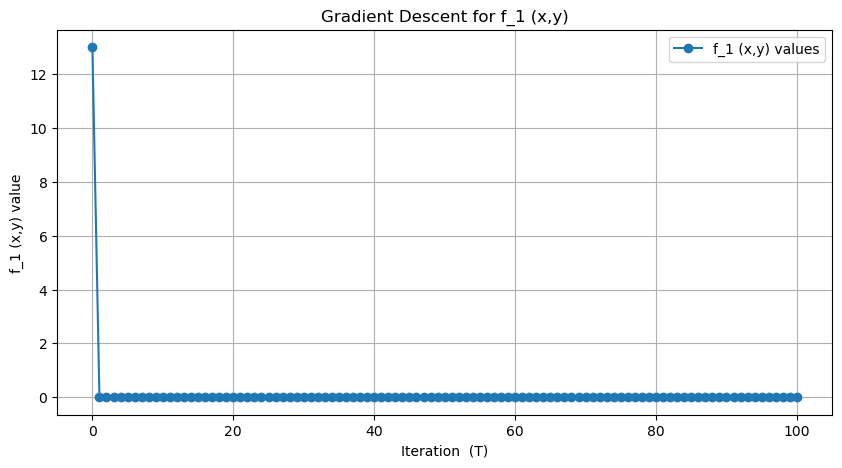

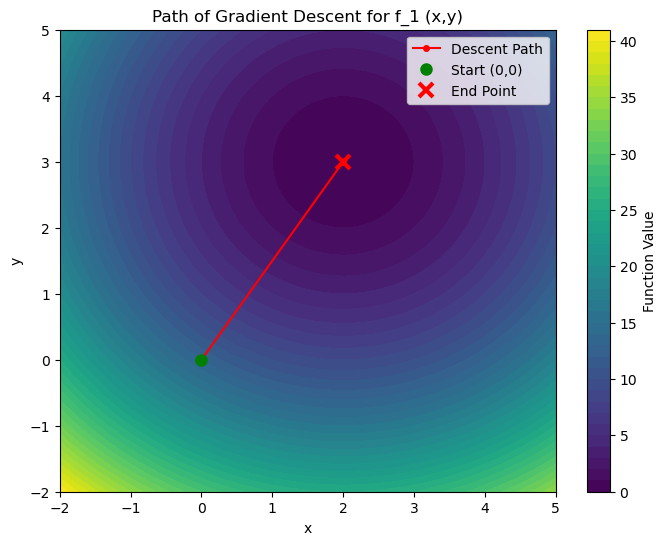

In [63]:
# Plotting for f_1 function
plt_GD(f_1_val_update, f_1_x_update, f_1_y_update, title="f_1 (x,y)", f=1)

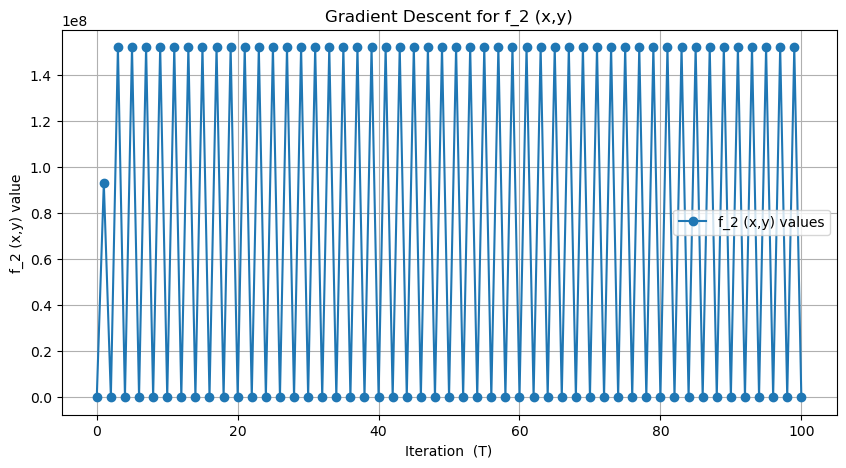

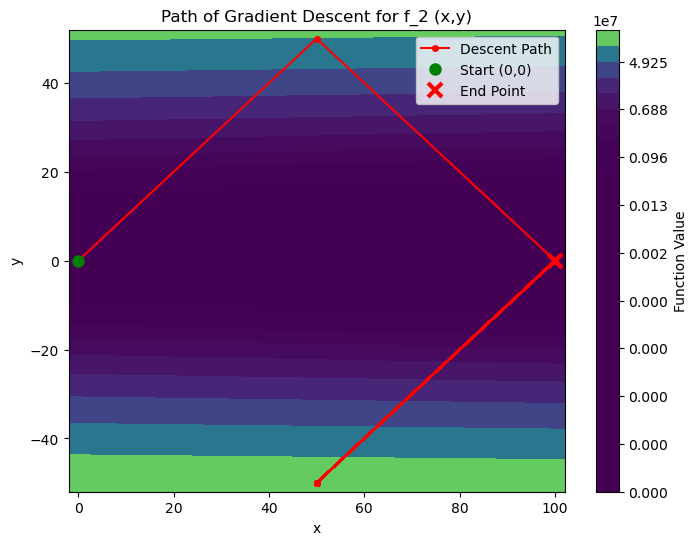

In [64]:
# Plotting for f_2 function
plt_GD(f_2_val_update, f_2_x_update, f_2_y_update, title="f_2 (x,y)", f=2)

$\eta=5$ appears to be sensitive for both functions. for f_1, while it leads directly to zero,it misses a smooth stepwise descent enterily, whereas for f_2, it is far too large, resultingin complete oversteps. As such, more subtle values of $\eta$ should be approached.

f_1(x,y); eta = 0.1

Gradient Descent for f1(x,y) with eta = 0.1
    Iteration - T        x        y      f1_value
0               1  0.40000  0.60000  8.320000e+00
1               2  0.72000  1.08000  5.324800e+00
2               3  0.97600  1.46400  3.407872e+00
3               4  1.18080  1.77120  2.181038e+00
4               5  1.34464  2.01696  1.395864e+00
..            ...      ...      ...           ...
95             96  2.00000  3.00000  3.215297e-18
96             97  2.00000  3.00000  2.057789e-18
97             98  2.00000  3.00000  1.316985e-18
98             99  2.00000  3.00000  8.428705e-19
99            100  2.00000  3.00000  5.394370e-19

[100 rows x 4 columns]


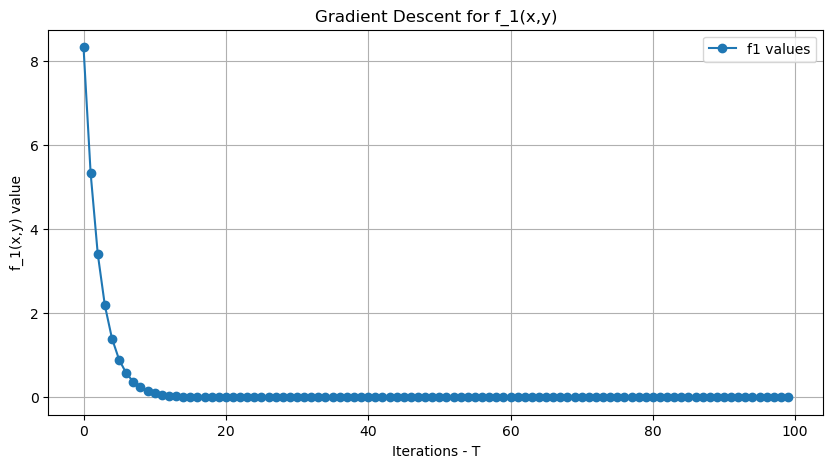

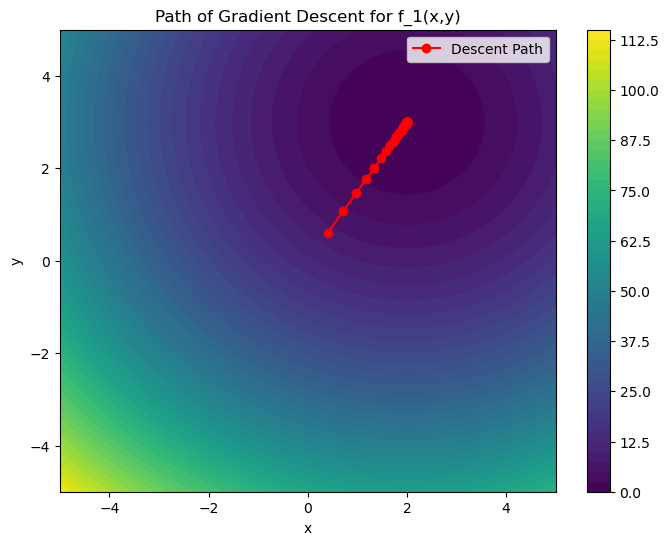

In [112]:
# applying gradient descent to find global mininum for x and y values for f_1(x,y)

# initialize x and y
x1 = 0;
y1 = 0; 

# set learning rate eta
eta = 0.1;

# set iteration number for T
T = 100;

# initialize arrays
f_1_x_update = [];
f_1_y_update = [];

# initialize update function f_1(x,y) array to plot global minimum
f_1_val_update = [];

for i in range(100):

    # Graidents for partial derivatves:

    # partial deriviate of f_1 with respect to x
    grad_x = 2*(x1-2)
  
    # partial derivative of f_1 with respect to y
    grad_y = 2*(y1-3)

    # updating x and y:
    x1 = x1 - eta*grad_x
    y1 = y1 - eta*grad_y

    # record x and y as arrays
    f_1_x_update.append(x1)
    f_1_y_update.append(y1)
    f_1_val_update.append((x1 - 2)**2 + (y1-3)**2)

# display updated x and y values as a table

xy_update_f_1 = pd.DataFrame({
    'Iteration - T': range(1, T + 1),
    'x': f_1_x_update,
    'y': f_1_y_update,
    'f1_value': f_1_val_update
})

print("Gradient Descent for f1(x,y) with eta = 0.1")
print(xy_update_f_1)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_1_val_update)),
    f_1_val_update,
    marker = 'o',
    label = 'f1 values'
)
plt.title('Gradient Descent for f_1(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_1(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path for f_1(x,y)
x1_vals = np.linspace(-5, 5, 100)
y1_vals = np.linspace(-5, 5, 100)
X1, Y1 = np.meshgrid(x1_vals, y1_vals)
Z1 = (X1-2)**2 + (Y1-3)**2

plt.figure(figsize=(8, 6))
contour1 = plt.contourf(X1, Y1, Z1, levels=50, cmap='viridis')
plt.colorbar(contour1)
plt.plot(f_1_x_update, f_1_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_1(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

f_2(x,y); eta = 0.00001

Gradient Descent for f2(x,y) with eta = 0.00001
    Iteration - T         x         y    f2_value
0               1  0.002400  0.014480  714.666161
1               2  0.004764  0.028677  694.149341
2               3  0.007094  0.042601  674.409982
3               4  0.009390  0.056258  655.410857
4               5  0.011652  0.069658  637.116911
..            ...       ...       ...         ...
95             96  0.135871  0.720933   95.482202
96             97  0.136694  0.724751   93.964296
97             98  0.137511  0.728530   92.477414
98             99  0.138319  0.732270   91.020798
99            100  0.139121  0.735972   89.593714

[100 rows x 4 columns]


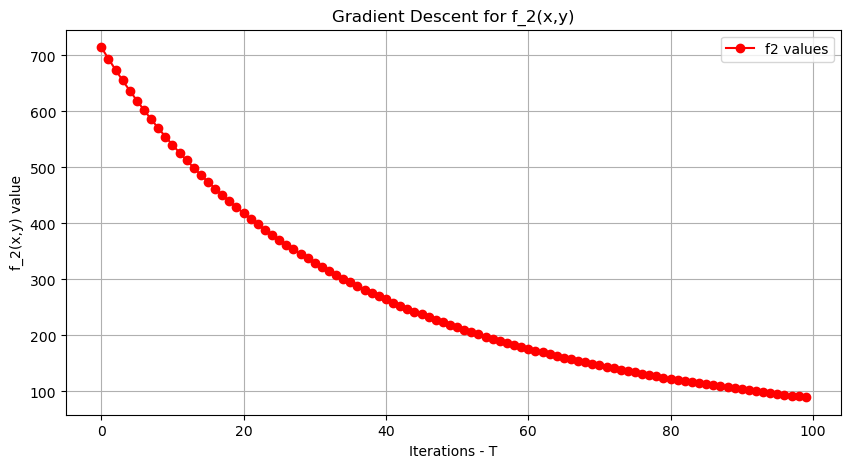

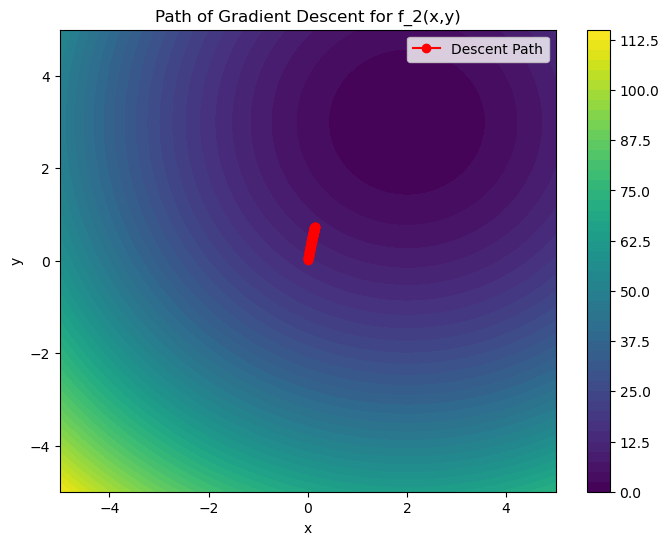

In [113]:
# initialize x and y
x2 = 0
y2 = 0

# set learning rate eta (note: a smaller eta value must be used)
eta2 = 0.00001

# set iteration number for T
T2 = 100

# initiazlie arrays to store values for x, y, and function value
f_2_x_update = []
f_2_y_update = []
f_2_val_update = []

for i in range(T2):
    # Gradients for partial derivatives of f_2:
    grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
    grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)
    
    # updating x and y
    x2 = x2 - eta2 * grad_x2
    y2 = y2 - eta2 * grad_y2
    
    # record the updated x and y
    f_2_x_update.append(x2)
    f_2_y_update.append(y2)
    
    # this line calculates and records the function's value
    f_2_val_update.append((1-(y2-3))**2 + 20*((x2+3)-(y2-3)**2)**2)

print("Gradient Descent for f2(x,y) with eta = 0.00001")
print(pd.DataFrame({
    'Iteration - T': range(1, T2 + 1), 
    'x': f_2_x_update, 
    'y': f_2_y_update, 
    'f2_value': f_2_val_update
    }))

# Visualizing Gradient descent for f_2(x,y)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_2_val_update)),
    f_2_val_update,
    marker = 'o',
    color = 'red',
    label = 'f2 values'
)
plt.title('Gradient Descent for f_2(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_2(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path
x2_vals = np.linspace(-5, 5, 100)
y2_vals = np.linspace(-5, 5, 100)
X2, Y2 = np.meshgrid(x2_vals, y2_vals)
Z2 = (X2-2)**2 + (Y2-3)**2

plt.figure(figsize=(8, 6))
contour2 = plt.contourf(X2, Y2, Z2, levels=50, cmap='viridis')
plt.colorbar(contour2)
plt.plot(f_2_x_update, f_2_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_2(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

One more attempt at using different eta values, with eta = 0.005 for f_1(x,y) and eta = 0.00005 for f_2(x,y)

f_1(x,y); eta = 0.005

Gradient Descent for f1(x,y) with eta = 0.005
    Iteration - T         x         y   f1_value
0               1  0.020000  0.030000  12.741300
1               2  0.039800  0.059700  12.487748
2               3  0.059402  0.089103  12.239242
3               4  0.078808  0.118212  11.995681
4               5  0.098020  0.147030  11.756967
..            ...       ...       ...        ...
95             96  1.237906  1.856859   1.887560
96             97  1.245527  1.868290   1.849997
97             98  1.253071  1.879607   1.813182
98             99  1.260541  1.890811   1.777100
99            100  1.267935  1.901903   1.741736

[100 rows x 4 columns]


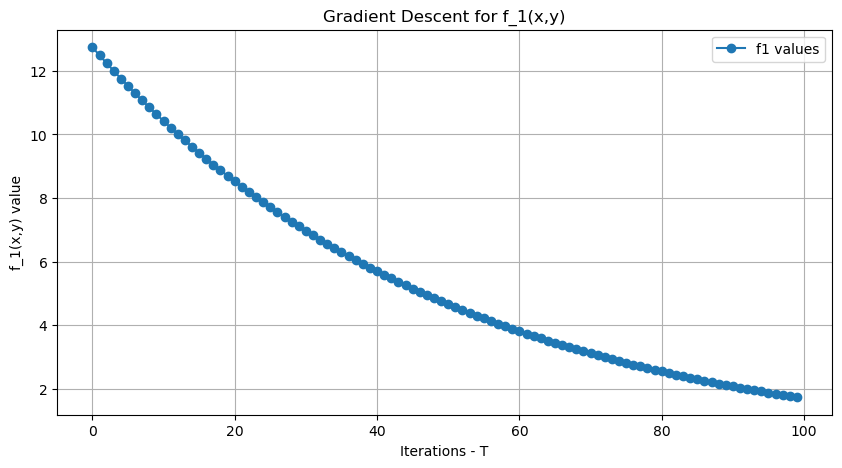

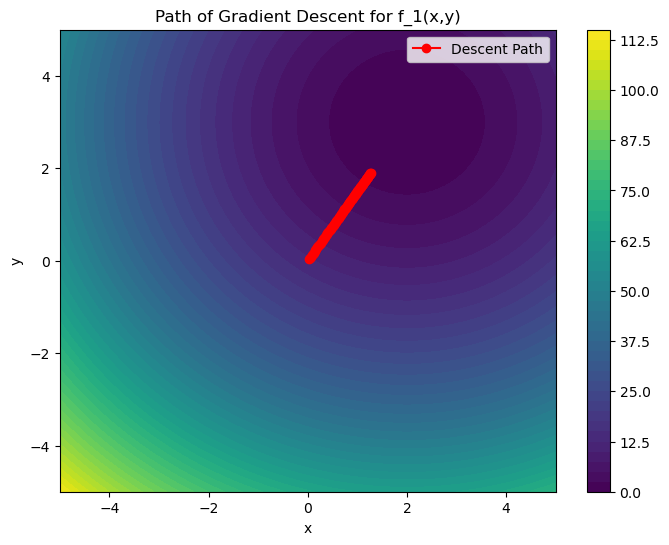

In [114]:
# applying gradient descent to find global mininum for x and y values for f_1(x,y)

# initialize x and y
x1 = 0;
y1 = 0; 

# set learning rate eta
eta = 0.005;

# set iteration number for T
T = 100;

# initialize arrays
f_1_x_update = [];
f_1_y_update = [];

# initialize update function f_1(x,y) array to plot global minimum
f_1_val_update = [];

for i in range(100):

    # Graidents for partial derivatves:

    # partial deriviate of f_1 with respect to x
    grad_x = 2*(x1-2)
  
    # partial derivative of f_1 with respect to y
    grad_y = 2*(y1-3)

    # updating x and y:
    x1 = x1 - eta*grad_x
    y1 = y1 - eta*grad_y

    # record x and y as arrays
    f_1_x_update.append(x1)
    f_1_y_update.append(y1)
    f_1_val_update.append((x1 - 2)**2 + (y1-3)**2)

# display updated x and y values as a table

xy_update_f_1 = pd.DataFrame({
    'Iteration - T': range(1, T + 1),
    'x': f_1_x_update,
    'y': f_1_y_update,
    'f1_value': f_1_val_update
})

print("Gradient Descent for f1(x,y) with eta = 0.005")
print(xy_update_f_1)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_1_val_update)),
    f_1_val_update,
    marker = 'o',
    label = 'f1 values'
)
plt.title('Gradient Descent for f_1(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_1(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path for f_1(x,y)
x1_vals = np.linspace(-5, 5, 100)
y1_vals = np.linspace(-5, 5, 100)
X1, Y1 = np.meshgrid(x1_vals, y1_vals)
Z1 = (X1-2)**2 + (Y1-3)**2

plt.figure(figsize=(8, 6))
contour1 = plt.contourf(X1, Y1, Z1, levels=50, cmap='viridis')
plt.colorbar(contour1)
plt.plot(f_1_x_update, f_1_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_1(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

f_2(x,y); eta = 0.00005

Gradient Descent for f2(x,y) with eta = 0.00005
    Iteration - T         x         y    f2_value
0               1  0.012000  0.072400  633.440476
1               2  0.023118  0.137889  549.196476
2               3  0.033455  0.197447  479.270778
3               4  0.043097  0.251870  420.691912
4               5  0.052115  0.301812  371.214186
..            ...       ...       ...         ...
95             96  0.237893  1.167169    8.319581
96             97  0.238136  1.168342    8.291298
97             98  0.238370  1.169481    8.264647
98             99  0.238595  1.170587    8.239531
99            100  0.238811  1.171662    8.215859

[100 rows x 4 columns]


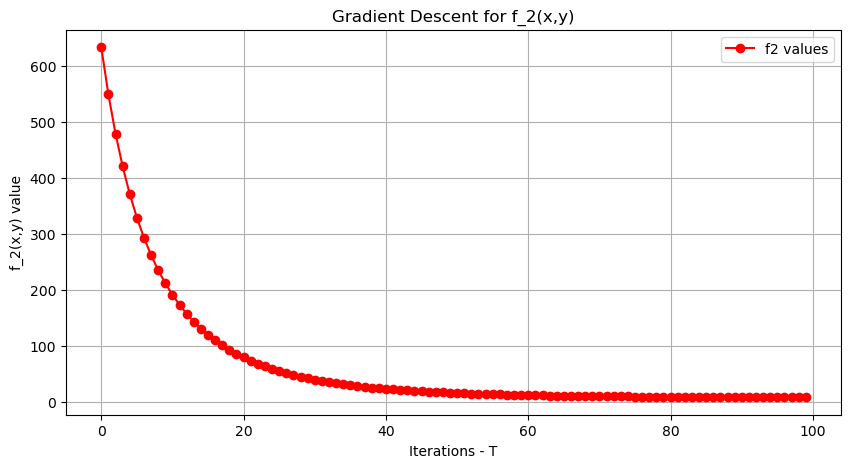

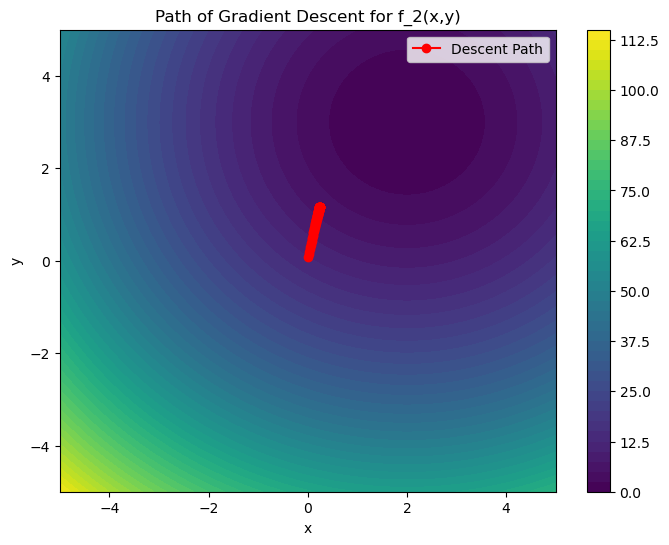

In [115]:
# initialize x and y
x2 = 0
y2 = 0

# set learning rate eta (note: a smaller eta value must be used)
eta2 = 0.00005

# set iteration number for T
T2 = 100

# initiazlie arrays to store values for x, y, and function value
f_2_x_update = []
f_2_y_update = []
f_2_val_update = []

for i in range(T2):
    # Gradients for partial derivatives of f_2:
    grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
    grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)
    
    # updating x and y
    x2 = x2 - eta2 * grad_x2
    y2 = y2 - eta2 * grad_y2
    
    # record the updated x and y
    f_2_x_update.append(x2)
    f_2_y_update.append(y2)
    
    # this line calculates and records the function's value
    f_2_val_update.append((1-(y2-3))**2 + 20*((x2+3)-(y2-3)**2)**2)

print("Gradient Descent for f2(x,y) with eta = 0.00005")
print(pd.DataFrame({
    'Iteration - T': range(1, T2 + 1), 
    'x': f_2_x_update, 
    'y': f_2_y_update, 
    'f2_value': f_2_val_update
    }))

# Visualizing Gradient descent for f_2(x,y)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_2_val_update)),
    f_2_val_update,
    marker = 'o',
    color = 'red',
    label = 'f2 values'
)
plt.title('Gradient Descent for f_2(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_2(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path
x2_vals = np.linspace(-5, 5, 100)
y2_vals = np.linspace(-5, 5, 100)
X2, Y2 = np.meshgrid(x2_vals, y2_vals)
Z2 = (X2-2)**2 + (Y2-3)**2

plt.figure(figsize=(8, 6))
contour2 = plt.contourf(X2, Y2, Z2, levels=50, cmap='viridis')
plt.colorbar(contour2)
plt.plot(f_2_x_update, f_2_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_2(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

From the previous exploration so far, it's appears that the mininum values for both f_1(x,y) and f_2(x,y) lie somewhere close to zero, as expceted for a global minium. More values can be explored but for the sake of brevity,  it appears that an eta value of 0.1 for f_1(x,y) and eta of 0.00005 appears to result in decent minimal values for the gradient. 

Gradient descent when applied to descending a function's partial derivative to find the optimal output for a function (via  a global mininum) is akin to going down a step hill. There may be several paths, some over rocky terrain, some over softer, but there exists a path that makes going down th hill more easire. That particular path is altered based on the direction of the steps taken to go down the hill along with determing how steep parts of the hill are. for both funcitons, f(x,y) can be though of as the position on the hill - the goal is to reach from the top to the bottom. As such, x and y can be though of the directions to step. Each step is adjusted based on the previous footing of the other step, i.e., the partial derivatives of the funciton with respect to x an dy. 

It should therefore follow from this hill example taht as gradient descent learning leads to a better path down the hill, adjusting the learning factor for functions f_1(x,y) and f_2(x,y). Rather go through a series of infinite values for x and y, the most best performing values can be found (or at least estimated) via gradient descent. similar to the hill analogy, the learning coefficient eta is vital as it sets the 'intensity' of the learning. the higher the eta value is, the more intense gradient descent, similar to over stepping or running when going down the hill. this can cause overshoots in reaching a global mininum. In turn, a too small of an eta value will result in a slower descent that may take even more iterations to go through, like stepping too slowly and too little when going down the hill resulting in a longer time going down. likewsise, a small eta value can be too computationally expesnive. As such, trade-offs need to be ackonwledged to reach a compromise as to an appropriate eta value.